In [ ]:
!wget -O exp-1-alan-turing.jpg "https://i.postimg.cc/nV6rMtzN/exp-1-alan-turing.jpg"

!wget -O exp-1-sunglass.png "https://i.postimg.cc/xCwxNdB6/exp-1-sunglass.png"

In [63]:
import cv2
import numpy as np

In [64]:
from google.colab.patches import cv2_imshow as imshow

In [65]:
img = cv2.imread("exp-1-alan-turing.jpg")
glasses = cv2.imread("exp-1-sunglass.png", cv2.IMREAD_UNCHANGED)

In [66]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [68]:
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

In [69]:
for (x, y, w, h) in faces:
    # Glasses size from face width
    gw = int(0.9 * w)
    gh = int(gw * glasses.shape[0] / glasses.shape[1])
    g = cv2.resize(glasses, (gw, gh))

    # Correct vertical placement (eye level)
    gx = x + (w - gw) // 2
    gy = y + int(0.42 * h) - gh // 2

    alpha = g[:, :, 3] / 255.0
    for c in range(3):
        img[gy:gy+gh, gx:gx+gw, c] = (
            alpha * g[:, :, c] +
            (1 - alpha) * img[gy:gy+gh, gx:gx+gw, c]
        )

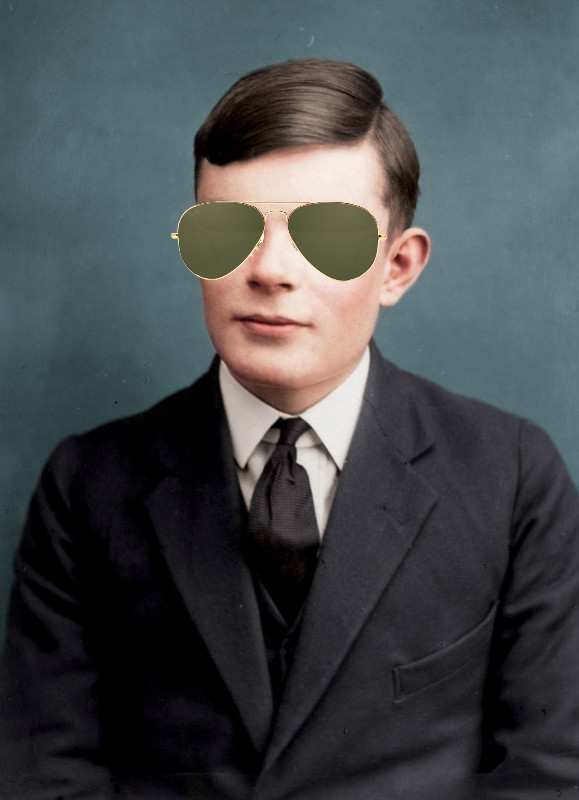

In [70]:
imshow(img)